In [1]:
# === project setup ===
from pathlib import Path
import sys

PROJECT_ROOT = Path().resolve().parents[0]
print("PROJECT_ROOT =", PROJECT_ROOT)

if not (PROJECT_ROOT / "src").exists():
    raise RuntimeError("src directory not found — wrong PROJECT_ROOT")

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

PROJECT_ROOT = D:\Resonance\TEP_analysis


In [2]:
# === imports ===
import pandas as pd 
import numpy as np 
from h5py import File
import json
import os 

# graphics
import matplotlib.pyplot as plt 
import seaborn as sns
from mne.viz import plot_topomap
from matplotlib.patches import Patch
import matplotlib.gridspec as gridspec

In [70]:
from src.utils.montage_processing import *
filename_colors = r"../resources/channel_colors.json"
with open(filename_colors, "r") as f:
    EEG64_REGION_COLOR = json.load(f)
CED_FILE = r"../resources/mks64_standard.ced"
df = pd.read_csv(CED_FILE, sep='\t')
df["colors"] = df["labels"].map(EEG64_REGION_COLOR)
colors = df["colors"].values

In [ ]:
import h5py
import os
folder = r"D:\2025 - TEP\data - trans\CLEAN_EPOCHS_UI"
filenames = os.listdir(folder)
filenames = np.asarray([filename for filename in filenames if filename.find("SOUND.mat") != -1])
session_dict = {
    "01AV": 38, 
    "04KK": 39, 
    "02NS": 41, 
    "03AZ": 40, 
    "07IK": 42, 
    "05UB": 43, 
    "08EN": 45, 
    "10ES": 52
}
def get_session_n(filename):
    return int(filename[filename.find("_")+1: filename.find("__")])
filenames = np.asarray([filename for filename in filenames if get_session_n(filename) in session_dict.values()])
print(session_dict.values())
print(filenames)


dict_values([38, 39, 41, 40, 42, 43, 45, 52])
['session_38__set_1__cleaned_SOUND.mat'
 'session_38__set_2__cleaned_SOUND.mat'
 'session_38__set_3__cleaned_SOUND.mat'
 'session_38__set_4__cleaned_SOUND.mat'
 'session_38__set_5__cleaned_SOUND.mat'
 'session_38__set_6__cleaned_SOUND.mat'
 'session_38__set_7__cleaned_SOUND.mat'
 'session_38__set_8__cleaned_SOUND.mat'
 'session_38__set_9__cleaned_SOUND.mat'
 'session_39__set_10__cleaned_SOUND.mat'
 'session_39__set_1__cleaned_SOUND.mat'
 'session_39__set_2__cleaned_SOUND.mat'
 'session_39__set_3__cleaned_SOUND.mat'
 'session_39__set_4__cleaned_SOUND.mat'
 'session_39__set_5__cleaned_SOUND.mat'
 'session_39__set_6__cleaned_SOUND.mat'
 'session_39__set_7__cleaned_SOUND.mat'
 'session_39__set_8__cleaned_SOUND.mat'
 'session_39__set_9__cleaned_SOUND.mat'
 'session_40__set_1__cleaned_SOUND.mat'
 'session_40__set_2__cleaned_SOUND.mat'
 'session_40__set_3__cleaned_SOUND.mat'
 'session_40__set_4__cleaned_SOUND.mat'
 'session_40__set_5__cleaned_SOUN

In [12]:
def decode_matlab_string_payload(ds):
    arr = np.asarray(ds[()]).ravel().astype(np.uint64)

    ndims = int(arr[1])
    shape = tuple(int(x) for x in arr[2:2 + ndims])
    n_items = int(np.prod(shape))

    lengths_start = 2 + ndims
    lengths = [int(x) for x in arr[lengths_start:lengths_start + n_items]]
    packed = arr[lengths_start + n_items:]

    codes = []
    for value in packed:
        codes.extend(
            np.frombuffer(int(value).to_bytes(8, "little"), dtype="<u2").tolist()
        )

    strings = []
    pos = 0
    for length in lengths:
        strings.append("".join(chr(c) for c in codes[pos:pos + length]))
        pos += length

    return np.array(strings, dtype=object).reshape(shape, order="F")

def read_matlab_string(f, dataset_path):
    desc = np.asarray(f[dataset_path][()]).ravel()
    mcos_index = int(desc[4]) + 1
    ref = f["#subsystem#/MCOS"][()].ravel()[mcos_index]
    return decode_matlab_string_payload(f[ref])


In [24]:
def get_orig_name(fn):
    with h5py.File(fn, "r") as hdf:
        orig = read_matlab_string(hdf, "cleanedResult/sourceDatasets/OriginalFile")
        orig = orig.ravel(order="F").tolist()
        return orig[0]

fl_dict = {}
for filename in filenames:
    fl_dict[str(filename)] = get_orig_name(os.path.join(folder, filename))
fl_dict

{'session_38__set_1__cleaned_SOUND.mat': '01_01AV_M1_PA_39MSO_real.hdf5',
 'session_38__set_2__cleaned_SOUND.mat': '02_01AV_M1_PA_39MSO_MI.hdf5',
 'session_38__set_3__cleaned_SOUND.mat': '03_01AV_M1_AP_43MSO_real.h5',
 'session_38__set_4__cleaned_SOUND.mat': '04_01AV_M1_AP_43MSO_MI.hdf5',
 'session_38__set_5__cleaned_SOUND.mat': '05_01AV_M1_PA_39MSO_real.hdf5',
 'session_38__set_6__cleaned_SOUND.mat': '06_01AV_M1_PA_39MSO_MI.hdf5',
 'session_38__set_7__cleaned_SOUND.mat': '07_01AV_M1_AP_43MSO_real.hdf5',
 'session_38__set_8__cleaned_SOUND.mat': '08_01AV_M1_AP_43MSO_MI.hdf5',
 'session_38__set_9__cleaned_SOUND.mat': '09_01AV_PPC_L_54MSO_real.hdf5',
 'session_39__set_10__cleaned_SOUND.mat': 'rest01_04KK_M1_PA_31MSO.hdf5',
 'session_39__set_1__cleaned_SOUND.mat': '01_04KK_M1_PA_32MSO_real.hdf5',
 'session_39__set_2__cleaned_SOUND.mat': '02_04KK_M1_PA_32MSO_MI.hdf5',
 'session_39__set_3__cleaned_SOUND.mat': '03_04KK_M1_AP_50MSO_real.hdf5',
 'session_39__set_4__cleaned_SOUND.mat': '04_04KK_

In [66]:
fn = os.path.join(folder, filenames[0])
def code_labels(labels, n):
    lab = np.zeros((n, 3))
    lab[np.where(labels == "animatedSingle1500_tms_+200ms_nosounds_bar.mkv"), 0] = 1
    lab[np.where(labels == "animatedSingle1500_tms_0ms_nosounds_bar.mkv"), 1] = 1
    lab[np.where(labels == "rest1500_tms_0ms_bar.mkv"), 2] = 1  
    return lab  

def get_data(fn):
    with h5py.File(fn, "r") as hdf:
        tvec = hdf['cleanedResult/tvec'][:][0]
        epoch  = hdf['cleanedResult/epochs_clean'][:] 
        
        label = read_matlab_string(hdf, "cleanedResult/epoch_types")
        label = label.ravel(order="F").tolist()
        labels = np.asarray([json.loads(stimulus)["stimulus"] for stimulus in label])
        lab = code_labels(labels, epoch.shape[1])

        orig = read_matlab_string(hdf, "cleanedResult/sourceDatasets/OriginalFile")
        orig = orig.ravel(order="F").tolist()
        return tvec, epoch, lab

In [69]:
subj = "01AV" 
cond = "real" 
spot = "M1_PA"

def get_epochs(subj, cond, spot, filenames):
    session_id = session_dict[subj] 
    epochs = []
    labels = []
    for filename in [fn for fn in filenames if fn.find(str(session_id)) != -1]:
        orig = get_orig_name(os.path.join(folder, filename))
        if orig.find(cond) != -1 and orig.find(spot) != -1:
            print("---", orig, "---", filename, "---")
            tvec, epoch, lab = get_data(os.path.join(folder, filename))
            epochs.append(epoch)
            labels.extend(lab)
    epochs = np.concat(epochs, axis=1)
    labels = np.asarray(labels)
    return epochs, labels, tvec

epochs, labels, tvec  = get_epochs(subj, cond, spot, filenames)
epochs.shape, labels.shape

--- 01_01AV_M1_PA_39MSO_real.hdf5 --- session_38__set_1__cleaned_SOUND.mat ---
--- 05_01AV_M1_PA_39MSO_real.hdf5 --- session_38__set_5__cleaned_SOUND.mat ---


((64, 150, 4001), (150, 3))

In [68]:
rest_mask = np.where(labels[:, 2] == 1)[0]
onset_mask = np.where(labels[:, 1] == 1)[0]
after_mask = np.where(labels[:, 0] == 1)[0]

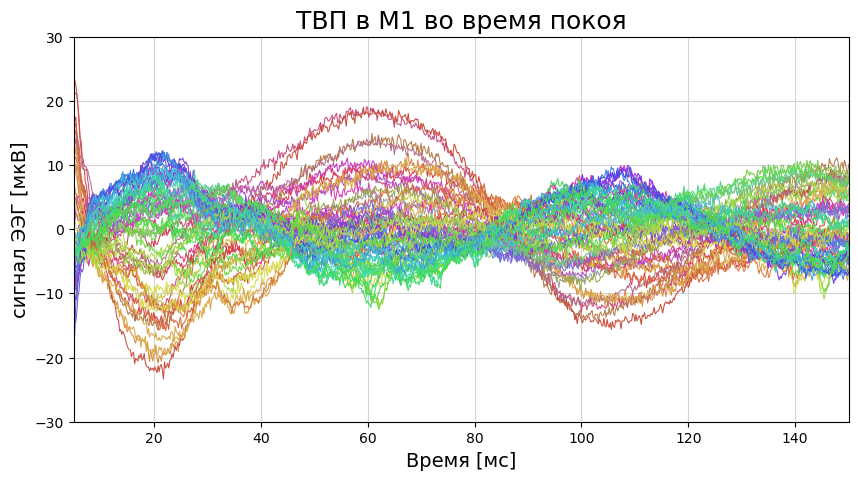

In [ ]:
tmin, tmax = 5, 150
amp = 30

n20 = (10, 25)
p30 = (20, 40)
n45 = (40, 55)
p60 = (55, 75)
n100 = (80, 140)
comps = [n20, p30, n45, p60, n100]

fig, ax = plt.subplots(1, 1, figsize=(10, 5))

TEPs = np.mean(epochs[:, rest_mask, :], axis=1)
for color, TEP in zip(colors, TEPs): # начало движения
    ax.plot(tvec, TEP, color=color, linewidth=.75)
ax.set_xlim(tmin, tmax)
ax.set_ylim(-amp, amp)
ax.set_xlabel("Время [мс]", fontsize=14)
ax.set_ylabel("сигнал ЭЭГ [мкВ]", fontsize=14)
ax.grid(color="lightgrey")



ax.set_title('ТВП в М1 во время покоя', fontsize=18)

ax.axvline(0, color="black", linewidth=2)

In [95]:
n20 = (10, 25)
p30 = (20, 40)
n45 = (40, 55)
p60 = (55, 75)
n100 = (80, 140)
comps = [n20, p30, n45, p60, n100]
funs = [np.min, np.max, np.min, np.max, np.min]
n_mean = 3
cond_names = ["rest", "onset", "after"]
comp_names = ["n20", "p30", "n45", "p60", "n100"]
df = []
for cond_mask, cond_name in zip([rest_mask, onset_mask, after_mask], cond_names):
    TEPs = np.mean(epochs[:, cond_mask, :], axis=1)
    for comp, fun, comp_name in zip(comps, funs , comp_names):
        time_mask = np.where((tvec>=comp[0]) & (tvec <=comp[1]))
        TEP = TEPs[:, time_mask]
        amp = fun(TEP, axis=0)
        amp_abs = np.mean(np.sort(np.abs(amp))[0][-n_mean:])
        df.append({
            "cond": cond_name, 
            "comp": comp_name, 
            "amp": round(amp_abs, 2)
        })

In [94]:
pd.DataFrame(df)

,cond,comp,ammp
0,rest,n20,22.629999
1,rest,p30,12.150000
2,rest,n45,10.800000
3,rest,p60,19.010000
4,rest,n100,15.480000
5,onset,n20,11.130000
6,onset,p30,11.000000
7,onset,n45,9.770000
8,onset,p60,13.720000
9,onset,n100,9.390000


In [19]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
filename = r"C:\Users\hodor\Documents\lab-MSU\Works\Конференции\Физиологическая им Павлова 2026\results.xlsx"
df_all= pd.read_excel(filename)

In [20]:
df = df_all.loc[(df_all.spot != "PPC_L") & (df_all.condition != "after")]

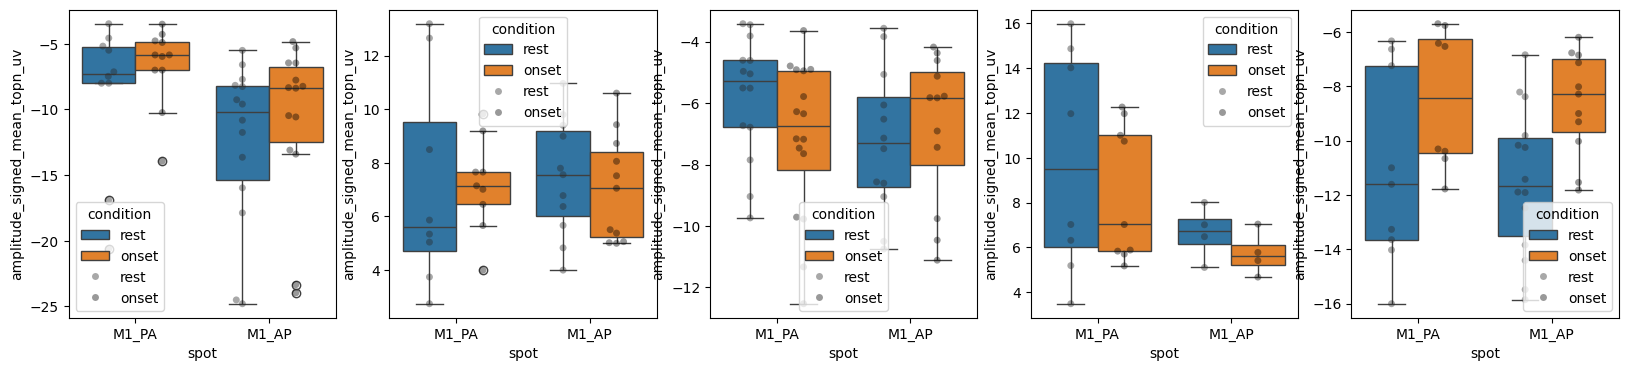

In [26]:
amp = "amplitude_signed_mean_topn_uv"
comp_names = ["n20", "p30", "n45", "p60", "n100"]
fig, ax = plt.subplots(1, len(comp_names), figsize=(20, 4))
for i, comp in enumerate(comp_names):
    sns.boxplot(df.loc[df.component == comp], y=amp, x="spot", hue="condition", ax=ax[i])
    sns.swarmplot(df.loc[df.component == comp], y=amp, x="spot", hue="condition", ax=ax[i], dodge=True, palette='dark:black', alpha=.4)